# **XGBoost Classifier**

### 1. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb

### 2. Creating a Classification Dataset
We will use `make_classification` from scikit-learn to generate a synthetic binary classification dataset.

In [ ]:
# Create a dataset with 1000 samples, 20 features (15 informative), and 2 classes (binary)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, n_redundant=5, 
                           n_classes=2, random_state=42)

# Convert to DataFrame to see the top features
df_X = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(1, 21)])
df_y = pd.Series(y, name='Target')

df_X.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Feature_13,Feature_14,Feature_15,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20
0,-4.906442,3.442789,0.558964,-0.976764,-1.568805,-4.271982,-3.727921,0.111868,2.119795,-2.522812,3.352281,-7.492478,4.264669,0.304866,0.777693,-9.375464,1.654446,3.012859,-4.497003,-2.520066
1,2.162610,-5.286651,2.609846,-1.803898,-1.831216,1.450757,2.648709,2.152307,0.524552,0.493548,-1.401809,6.680603,-2.431830,2.462773,-1.254824,2.978402,-3.428457,-4.562178,3.698665,-1.923286
2,-4.784844,-3.744827,4.657592,-1.408806,-5.444758,-2.416013,3.556495,-1.572119,-0.730549,3.447661,-2.609052,7.961059,-5.151105,0.473131,-4.070667,-0.932309,-3.230768,-7.844646,2.803798,-2.963189
3,10.465024,1.070944,-3.562432,-0.849062,2.183860,-0.609893,0.946327,-1.046141,-2.057053,-2.056650,-2.215455,-1.449095,-1.217685,2.026805,2.121829,3.184256,-1.960146,0.782147,-1.444202,0.915985
4,5.599516,-1.776412,-1.304322,-0.720074,5.859373,-3.292432,3.152205,7.099882,-3.321076,3.245486,-0.336178,6.608729,5.632297,-1.943748,1.169455,3.782513,-4.752822,-7.577624,4.868025,1.708210


### 3. Splitting the Dataset
Divide the data into training (80%) and testing (20%) sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (800, 20)
Testing set shape: (200, 20)


### 4. Training the XGBoost Classifier
We initialize and train the `XGBClassifier`. Because this is a binary classification problem, we will use the `binary:logistic` objective.

In [ ]:
# Initialize XGBoost Classifier
xg_clf = xgb.XGBClassifier(objective='binary:logistic', colsample_bytree=0.5, 
                           learning_rate=0.1, max_depth=5, alpha=10, n_estimators=100)

# Fit the model to the training data
xg_clf.fit(X_train, y_train)

XGBClassifier(alpha=10, base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, ...)

# XGBoost Classifier: A Simple Guide to Hyperparameters

Training an XGBoost Classifier is very similar to the Regressor, but with a different focus (`objective`) and some classification-specific nuances.

Here is a breakdown of the most commonly used `XGBClassifier` hyperparameters:


### 1. General Parameters (The Ensembles)

**`n_estimators`** (Default: 100)
*   **What it is:** The number of decision trees in the ensemble.
*   **How to tune:** Higher values create a more powerful model but take longer to train. Too many trees can lead to overfitting, so it's usually paired with `early_stopping_rounds`.

**`learning_rate`** (or `eta`) (Default: 0.3)
*   **What it is:** The step size shrinkage used at each update to prevent overfitting. 
*   **How to tune:** A smaller learning rate makes the model learn slower but usually results in a better, more generalized model. If you lower this (e.g., to 0.05 or 0.1), you usually need to increase `n_estimators`.

**`objective`** (Default: `binary:logistic` for binary, `multi:softprob` for multi-class)
*   **What it is:** The mathematical loss function the model tries to minimize.
*   **How to tune:** Use `binary:logistic` if predicting Yes/No, and `multi:softmax` or `multi:softprob` if predicting multiple categories (like Red/Green/Blue).

    - For Binary Classification (Predicting Yes or No / 0 or 1)
        - e.g., Predicting if an email is Spam (1) or Not Spam (0).
        - `binary:logistic`: The standard choice. This trains a logistic regression model. It will output a probability between 0.0 and 1.0 (e.g., "There is an 85% chance this is Spam").
        - `binary:logitraw`: This trains the exact same logic, but it outputs the raw, un-transformed score (logit) before it gets converted into a 0.0 to 1.0 probability. You rarely need this unless you are doing custom mathematical transformations downstream.
        - `binary:hinge`: This is for making hard predictions (it just outputs exactly 0 or exactly 1). It does not give you a probability. It is useful when you just want a definitive answer.

    - For Multi-Class Classification (Predicting Categories)
        - e.g., Predicting if an animal is a Dog, Cat, or Bird.
        - `multi:softmax`: You must specify num_class (how many categories you have). This will return the exact predicted class label (e.g., it will output "Cat").
        - `multi:softprob`: You must specify num_class. Instead of giving you the exact label, it will give you the probability for each category (e.g., "10% Dog, 80% Cat, 10% Bird").

### 2. Tree-Specific Parameters (Shape of the Decision Trees)

**`max_depth`** (Default: 6)
*   **What it is:** The maximum depth of each individual decision tree.
*   **How to tune:** Higher depth captures highly specific (and complex) patterns, but is extremely prone to overfitting. A typical starting point is between 3 and 10.

**`min_child_weight`** (Default: 1)
*   **What it is:** The minimum sum of instance weight (data points) needed in a final leaf node.
*   **How to tune:** Increasing this forces the model to be more conservative. It stops the tree from creating a split just to accommodate a few crazy outliers.

**`gamma`** (Default: 0)
*   **What it is:** The minimum loss reduction required to make a split.
*   **How to tune:** Setting a higher value (like 1, 5, or 10) acts as an aggressive pruning mechanism, preventing the tree from splitting unless it significantly improves accuracy.


### 3. Subsampling and Randomness (Preventing Memorization)

**`subsample`** (Default: 1.0)
*   **What it is:** The percentage of rows (samples) used per tree.
*   **How to tune:** Setting this to 0.8 means each tree only gets to look at a random 80% of the data. This forced randomness helps prevent overfitting.

**`colsample_bytree`** (Default: 1.0)
*   **What it is:** The percentage of columns (features) used per tree.
*   **How to tune:** Setting this to 0.8 means each tree can only use a random 80% of the features. It forces the model to learn from all features rather than relying on one or two dominant ones.


### 4. Regularization Parameters

**`alpha`** / **`reg_alpha`** (Default: 0)
*   **What it is:** L1 regularization on weights (Lasso).
*   **How to tune:** It pushes the weights of unimportant features to exactly 0, effectively removing them. Helpful for highly dimensional, sparse data.

**`lambda`** / **`reg_lambda`** (Default: 1)
*   **What it is:** L2 regularization on weights (Ridge).
*   **How to tune:** Shrinks the weights of features to prevent the model from heavily relying on any single one. Increasing this makes the model more robust.


### 5. Making Predictions and Evaluating the Model
Let's test the model on our 20% holdout test set to see how accurately it classifies the two categories.

In [ ]:
# Predict the classes on the test set
preds = xg_clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, preds)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, preds))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, preds))

Accuracy: 88.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       100
           1       0.88      0.88      0.88       100

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.88      0.88       200

Confusion Matrix:
[[88 12]
 [12 88]]


### 6. Visualizing Feature Importance
XGBoost provides a great method to visualize which features contributed the most to the classification decisions.

<Figure size 1000x800 with 0 Axes>

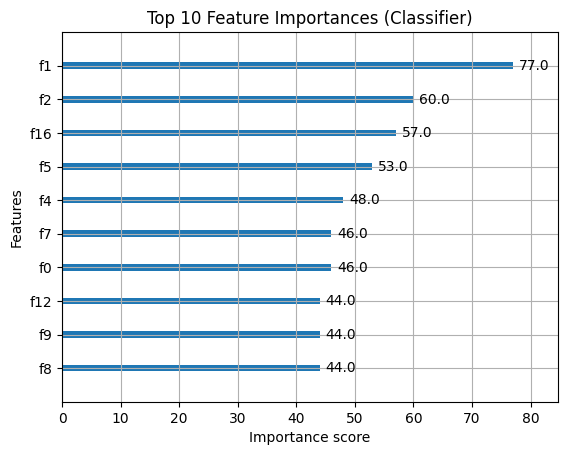

In [ ]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(xg_clf, max_num_features=10, importance_type='weight')
plt.title('Top 10 Feature Importances (Classifier)')
plt.show()